# CRISP-DM na Prática: Previsão de Churn em Plataforma de Streaming

## Fase 4: Modelagem

In [8]:
# separação do conjunto de treino, validação e teste

X, y = df_padronizado.drop('Churn',axis=1), df_padronizado['Churn'] # separando as features e o target

# treino e teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#X_temp, X_test, y_temp, y_test -> vão pegar o dado original e separar em 80% pra treino e 20% pra teste

# treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

# A partir dos dados originais separados para treino vamos criar o conjunto de validação. Ou seja, dos 80% separado
# para treino, vamos separá-lo em 75% para treino e 25% para validação.


In [9]:
# vamos utilizar uma técnica de oversampling para separarmos as variáveis de treino e teste de forma balanceada

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print(sorted(Counter(y_resampled).items()))

[(0.0, 1710), (1.0, 1710)]


### Aplicando os modelos

* XGboost
* Regressão logística

Xgboost

In [10]:
# XGboost

from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    scale_pos_weight=1,  # após oversampling
    eval_metric='logloss'
)


In [11]:
# treinando o modelo

xgboost_model.fit(X_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Analisando a importância das features no treinamento do modelo

In [12]:
importances = xgboost_model.feature_importances_

df_importances = pd.DataFrame({
    'feature': X_resampled.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

df_importances

,feature,importance
8,ContractRenewal,0.355623
2,CustServCalls,0.179718
3,DayMins,0.110370
1,DataUsage,0.089637
5,MonthlyCharge,0.085636
6,OverageFee,0.051203
7,RoamMins,0.046620
0,AccountWeeks,0.045512
4,DayCalls,0.035681
9,DataPlan,0.000000


Como visto, algumas features obtém zero ou pouquíssima relevância para o treinamento do modelo. Logo, vou retreinar deixando apenas aquelas acima do limite de 0.05.

In [13]:
X_fi, y_fi = df_padronizado.drop(['Churn','DataPlan','DayCalls','AccountWeeks','RoamMins'],axis=1), df_padronizado['Churn'] # separando as features e o target

# treino e validação
X_temp_fi, X_test_fi, y_temp_fi, y_test_fi = train_test_split(
    X_fi, y_fi, test_size=0.2, stratify=y, random_state=42
)

#X_temp, X_test, y_temp, y_test -> vão pegar o dado original e separar em 80% pra treino e 20% pra teste

# treino e validação
X_train_fi, X_val_fi, y_train_fi, y_val_fi = train_test_split(
    X_temp_fi, y_temp_fi, test_size=0.25, stratify=y_temp, random_state=42
)

# balanceando os dados
ros_fi = RandomOverSampler(random_state=42)
X_resampled_fi, y_resampled_fi = ros_fi.fit_resample(X_train_fi, y_train_fi)

xgboost_model_fi = XGBClassifier(
    scale_pos_weight=1,  # após oversampling
    eval_metric='logloss'
)


# aplicando o modelo
xgboost_model_fi.fit(X_resampled_fi, y_resampled_fi)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Regressão Logística

In [14]:
# Regressão Logística

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)


In [15]:
# treinando o modelo
lr_model.fit(X_resampled, y_resampled)

LogisticRegression(max_iter=1000)

## Fase 5: Avaliação

In [16]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def avaliar_modelo(model, X_val, y_val, nome):
    y_prob = model.predict_proba(X_val)[:,1]
    y_pred = (y_prob >= 0.5).astype(int)

    print(f'\n {nome}')
    print('ROC AUC:', roc_auc_score(y_val, y_prob))
    print('PR AUC:', average_precision_score(y_val, y_prob))
    print(classification_report(y_val, y_pred, digits=4))


In [22]:
avaliar_modelo(lr_model, X_val, y_val, 'Logistic Regression')
avaliar_modelo(xgboost_model, X_val, y_val, 'XGBoost sem Feature Importance')
avaliar_modelo(xgboost_model_fi, X_val_fi, y_val_fi, 'XGBoost com Feature Importance')


 Logistic Regression
ROC AUC: 0.8343823476216315
PR AUC: 0.4824694959909689
              precision    recall  f1-score   support

         0.0     0.9566    0.7737    0.8555       570
         1.0     0.3738    0.7938    0.5083        97

    accuracy                         0.7766       667
   macro avg     0.6652    0.7837    0.6819       667
weighted avg     0.8719    0.7766    0.8050       667


 XGBoost sem Feature Importance
ROC AUC: 0.8987701211792367
PR AUC: 0.8040591499729777
              precision    recall  f1-score   support

         0.0     0.9531    0.9632    0.9581       570
         1.0     0.7692    0.7216    0.7447        97

    accuracy                         0.9280       667
   macro avg     0.8612    0.8424    0.8514       667
weighted avg     0.9264    0.9280    0.9271       667


 XGBoost com Feature Importance
ROC AUC: 0.8976668475311992
PR AUC: 0.7598328703778374
              precision    recall  f1-score   support

         0.0     0.9459    0.9509    0

Observamos que o modelo de XGboost sen a feature importance obtém um melhor desempenho do que o de Regressão logística em relação as métricas de Acurácia, Precision e Recall. Abaixo vamos analisar a curva ROC.

**Curva ROC**

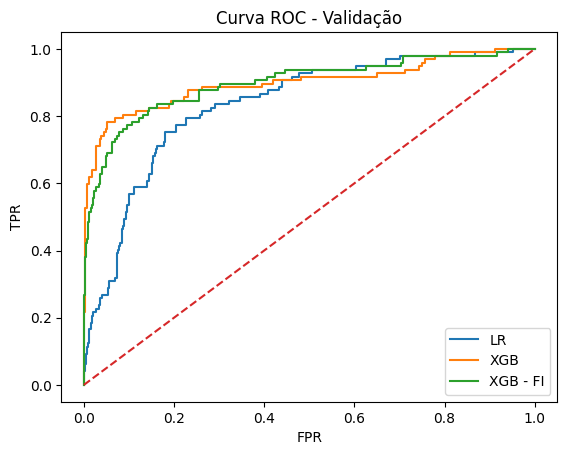

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

models = {'LR': lr_model, 'XGB': xgboost_model, 'XGB - FI': xgboost_model_fi}

for name, model in models.items():
  if name == "LR" or name == "XGB":
      y_prob = model.predict_proba(X_val)[:,1]
      fpr, tpr, _ = roc_curve(y_val, y_prob)
  else:
      y_prob = model.predict_proba(X_val_fi)[:,1]
      fpr, tpr, _ = roc_curve(y_val_fi, y_prob)

  plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], '--')
plt.legend()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC - Validação')
plt.show()



XGBoost apresenta o melhor desempenho, sendo assim para poucos falsos positivos, o XGBoost já captura muitos churns. A regressão logística precisa “errar mais” para alcançar o mesmo recall.

## Fase 6: Implantação

In [18]:
X_val

,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,ContractRenewal,DataPlan
2930,0.576028,-0.641642,-0.427932,-0.346591,0.426808,-0.992790,-1.120756,0.953889,1.0,0.0
2769,0.902529,-0.460892,-0.427932,-0.445748,-0.968582,-0.974524,-1.337690,-0.407425,1.0,0.0
917,-0.729976,-0.641642,-1.188218,-1.297762,-0.171217,-1.662560,-1.680841,-0.694017,1.0,0.0
2145,0.098834,-0.382305,-0.427932,0.255694,0.376972,-0.243867,-0.351626,0.201584,1.0,0.0
1187,1.028106,0.607889,0.332354,0.747805,-0.320723,1.071317,0.760655,-1.553794,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...
373,-1.734594,-0.641642,0.332354,-0.274978,-0.121381,-0.505686,0.571330,1.634546,1.0,0.0
2046,0.475566,-0.641642,-0.427932,-0.561431,-0.121381,-0.871014,-0.146524,0.309056,1.0,0.0
1988,-1.056476,-0.311577,-0.427932,-0.543069,-1.516771,-0.615284,-0.300351,0.667297,1.0,0.0
2044,-0.529052,1.480204,-1.188218,0.081252,1.573021,1.016517,-0.659278,-0.085008,0.0,1.0


In [19]:
# analisando a faixa de risco do score

y_val_prob = xgboost_model.predict_proba(X_val)[:, 1] # selecionando no array da probabilidade apenas os casos com churn

df_val = X_val.copy()
df_val['y_true'] = y_val.values # selecionando a variável de churn para o dataset de validação
df_val['prob_churn'] = y_val_prob # valores previstos a partir do treinamento do modelo

df_val['risk_band'] = pd.qcut(
    df_val['prob_churn'],
    q=[0, 0.33, 0.66, 1.0], # faixa de risco
    labels=['Baixo', 'Médio', 'Alto']
)


In [20]:
df_val.head()

,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,ContractRenewal,DataPlan,y_true,prob_churn,risk_band
2930,0.576028,-0.641642,-0.427932,-0.346591,0.426808,-0.992790,-1.120756,0.953889,1.0,0.0,0.0,0.000128,Baixo
2769,0.902529,-0.460892,-0.427932,-0.445748,-0.968582,-0.974524,-1.337690,-0.407425,1.0,0.0,0.0,0.000407,Baixo
917,-0.729976,-0.641642,-1.188218,-1.297762,-0.171217,-1.662560,-1.680841,-0.694017,1.0,0.0,0.0,0.005222,Médio
2145,0.098834,-0.382305,-0.427932,0.255694,0.376972,-0.243867,-0.351626,0.201584,1.0,0.0,0.0,0.002971,Médio
1187,1.028106,0.607889,0.332354,0.747805,-0.320723,1.071317,0.760655,-1.553794,1.0,1.0,0.0,0.001497,Baixo


In [21]:
summary = (
    df_val
    .groupby('risk_band')
    .agg(
        clientes=('y_true', 'count'),
        churn_rate=('y_true', 'mean')
    )
    .reset_index()
)

summary


/tmp/ipython-input-485496518.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('risk_band')


,risk_band,clientes,churn_rate
0,Baixo,220,0.036364
1,Médio,220,0.018182
2,Alto,227,0.374449


Este resultado nos indica que o modelo consegue identificar bem a parcela do churn para aqueles como risco alto. Então, numa ação de retenção conseguiríamos atingir uma boa parcela. Contudo, considerando a faixa baixa e média ele não consegue distinguir muito bem os dois grupos.